Se encontraron 8 archivos

Procesando cell104basal.abf
Duración total: 258.00 s
Spikes: 974
Bursts: 50

Procesando cell105basal.abf
Duración total: 193.50 s
Spikes: 735
Bursts: 18

Procesando cell107basal.abf
Duración total: 322.50 s
Spikes: 395
Bursts: 16

Procesando cell209basal.abf
Duración total: 129.00 s
Spikes: 29
Bursts: 5

Procesando cell21basal.abf
Duración total: 193.50 s
Spikes: 43
Bursts: 6

Procesando cell89basal.abf
Duración total: 645.00 s
Spikes: 4214
Bursts: 198

Procesando cell91basal.abf
Duración total: 193.50 s
Spikes: 622
Bursts: 32

Procesando cell98basal.abf
Duración total: 451.50 s
Spikes: 154
Bursts: 10

Proceso finalizado correctamente
           file  burst  start_s    end_s  duration_s  n_spikes  mean_isi_s  \
0  cell104basal      0   3.2011   3.6654      0.4643        21    0.023215   
1  cell104basal      1  14.7754  15.2606      0.4852        23    0.022055   
2  cell104basal      2  45.5475  45.8115      0.2640        17    0.016500   
3  cell104basal   

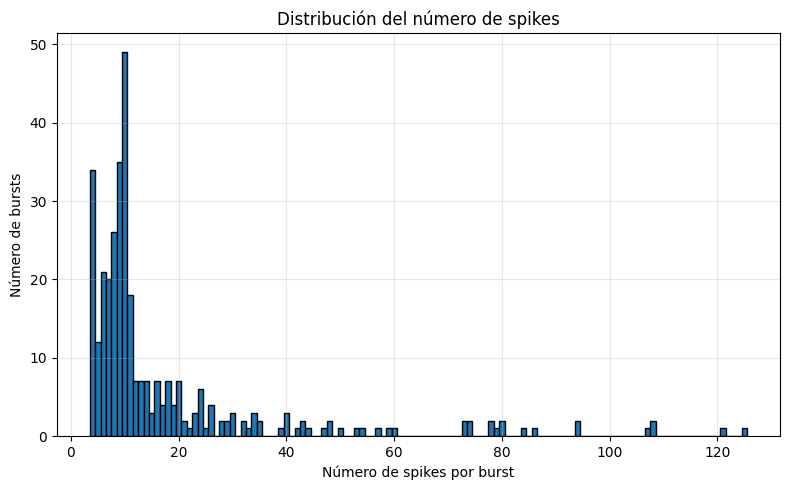


Grupos creados automáticamente:

G1  ->  [np.int64(4)]  (34 bursts)
G10  ->  [np.int64(43), np.int64(44), np.int64(47), np.int64(48), np.int64(50), np.int64(53), np.int64(54), np.int64(57), np.int64(59), np.int64(60), np.int64(73), np.int64(74), np.int64(78), np.int64(79), np.int64(80), np.int64(84), np.int64(86), np.int64(94), np.int64(107), np.int64(108), np.int64(121), np.int64(125)]  (30 bursts)
G2  ->  [np.int64(5), np.int64(6)]  (33 bursts)
G3  ->  [np.int64(7), np.int64(8)]  (46 bursts)
G4  ->  [np.int64(9)]  (35 bursts)
G5  ->  [np.int64(10)]  (49 bursts)
G6  ->  [np.int64(11), np.int64(12)]  (25 bursts)
G7  ->  [np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17)]  (28 bursts)
G8  ->  [np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]  (30 bursts)
G9  ->  [np.int64(25), np.int64(26), np.int64(28), np.int64(29), np.int64(30), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(39), np.int64(40), np.i

In [ ]:
#IMPORT LIBRARIES
from pathlib import Path          
import os                         
import numpy as np                
import pandas as pd               
import matplotlib.pyplot as plt   
import pyabf                      
from scipy import signal          
from scipy.signal import find_peaks  

# CONFIGURATION
# Directory containing the input ABF recordings
INPUT_FOLDER = "bursting"
# Directory where the processed data will be stored
OUTPUT_FOLDER = "processed_bursts"
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# Spike detection parameters 
THRESH_MIN = -35            # Minimum spike amplitude (mV)
THRESH_PROMINENCE = 15      # Minimum spike prominence (mV)
MIN_WIDTH_MS = 0.3          # Minimum spike width (ms)
MIN_DISTANCE_MS = 1.0       # Minimum distance between consecutive spikes (ms)

# Burst detection parameters 
BURST_ISI_THRESHOLD = 0.30  # Maximum inter-spike interval (ISI) within a burst (s)
MIN_SPIKES_PER_BURST = 4    # Minimum number of spikes required per burst
MIN_BURST_DURATION = 0.05   # Minimum burst duration (s)

# Signal filtering parameters
FILTER = True               # Enable or disable filtering
LOWPASS = 2000              # Low-pass filter cutoff frequency (Hz)

# Search for all ABF files whose names start with "cell"
files = sorted(Path(INPUT_FOLDER).glob("cell*.abf"))
print(f"Found {len(files)} files")

# List used to store the features extracted from all bursts
dataset = []

# PROCESS EACH ABF RECORDING
for file in files:

    print(f"\nProcessing {file.name}")

    # Load the ABF recording
    abf = pyabf.ABF(str(file))

    # Sampling frequency (Hz)
    fs = int(abf.dataPointsPerMs * 1000)

    # CONCATENATE ALL SWEEPS
    # Concatenate all sweeps into a single continuous recording
    time_all = []
    voltage_all = []
    offset = 0.0
    for sweep in abf.sweepList:
        # Select the current sweep
        abf.setSweep(sweep)
        # Copy time and voltage signals
        t = abf.sweepX.copy()
        v = abf.sweepY.copy()
        # Shift the time vector to obtain a continuous recording
        t = t + offset
        time_all.append(t)
        voltage_all.append(v)
        # Update the time offset for the next sweep
        offset = t[-1] + (t[1] - t[0])
    # Merge all sweeps into a single signal
    time = np.concatenate(time_all)
    voltage = np.concatenate(voltage_all)
    print(f"Total recording duration: {time[-1]:.2f} s")

    # SIGNAL FILTERING
    if FILTER:
        # Fourth-order low-pass Bessel filter
        b, a = signal.bessel(
            N=4,
            Wn=LOWPASS,
            btype="low",
            fs=fs,
            norm="phase"
        )
        # Zero-phase filtering to avoid phase distortion
        voltage = signal.filtfilt(b, a, voltage)

    # SPIKE DETECTION
    peaks, _ = find_peaks(
        voltage,
        height=THRESH_MIN,
        prominence=THRESH_PROMINENCE,
        width=MIN_WIDTH_MS * fs / 1000,
        distance=MIN_DISTANCE_MS * fs / 1000
    )
    # Skip the recording if no spikes are detected
    if len(peaks) == 0:
        continue

    # Time of occurrence of each detected spike
    spike_times = time[peaks]

    # BURST DETECTION USING THE ISI METHOD
    # Compute the inter-spike intervals (ISI)
    isi = np.diff(spike_times)
    bursts = []
    current = [0]

    # Group consecutive spikes whose ISI is below the threshold
    for i in range(len(isi)):
        if isi[i] < BURST_ISI_THRESHOLD:
            current.append(i + 1)
        else:
            bursts.append(current)
            current = [i + 1]
    bursts.append(current)

    # BURST FILTERING
    valid_bursts = []
    burst_number = 1

    # OVERVIEW PLOT OF THE RECORDING
    fig, ax = plt.subplots(figsize=(18, 5))
    # Plot the complete voltage trace
    ax.plot(time, voltage, color="black", lw=0.3)
    # Mark detected spikes
    ax.plot(spike_times, voltage[peaks], "r.", markersize=4)
    # Evaluate each candidate burst
    for burst in bursts:
        # Discard bursts with too few spikes
        if len(burst) < MIN_SPIKES_PER_BURST:
            continue
        first = peaks[burst[0]]
        last = peaks[burst[-1]]
        t0 = time[first]
        tf = time[last]

        # Discard bursts shorter than the minimum duration
        if (tf - t0) < MIN_BURST_DURATION:
            continue
        valid_bursts.append(burst)

        # Highlight the burst interval
        ax.axvspan(t0, tf, color="limegreen", alpha=0.25)
        # Label the burst
        ax.text(
            (t0 + tf) / 2,
            np.max(voltage),
            str(burst_number),
            ha="center",
            color="green"
        )
        burst_number += 1

    ax.set_title(file.stem)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Voltage (mV)")

    plt.tight_layout()

    # Save the overview figure
    plt.savefig(
        os.path.join(OUTPUT_FOLDER, f"{file.stem}_overview.png"),
        dpi=300
    )

    plt.close()
    print(f"Detected spikes: {len(peaks)}")
    print(f"Detected bursts: {len(valid_bursts)}")

    # SAVE EACH BURST
    burst_id = 0

    for burst in valid_bursts:

        first_peak = peaks[burst[0]]
        last_peak = peaks[burst[-1]]

        t0 = time[first_peak]
        tf = time[last_peak]

        # Temporal margin added before and after each burst
        margin = 0.10

        # Extract only the burst segment
        mask = (time >= t0 - margin) & (time <= tf + margin)
        burst_time = time[mask] - time[mask][0]
        burst_voltage = voltage[mask]

        # Save the time and voltage arrays
        np.save(
            os.path.join(
                OUTPUT_FOLDER,
                f"{file.stem}_burst_{burst_id:03d}_time.npy"
            ),
            burst_time
        )

        np.save(
            os.path.join(
                OUTPUT_FOLDER,
                f"{file.stem}_burst_{burst_id:03d}_voltage.npy"
            ),
            burst_voltage
        )

        # FEATURE EXTRACTION
        burst_spike_times = spike_times[burst]
        isi_b = np.diff(burst_spike_times)
        dataset.append({

            "file": file.stem,
            "burst": burst_id,
            "start_s": t0,
            "end_s": tf,
            "duration_s": tf - t0,
            "n_spikes": len(burst),
            "mean_isi_s": np.mean(isi_b) if len(isi_b) else np.nan,
            "std_isi_s": np.std(isi_b) if len(isi_b) else np.nan,
            "mean_frequency_hz": (1 / np.mean(isi_b)) if len(isi_b) else np.nan,
            "max_voltage": np.max(burst_voltage),
            "min_voltage": np.min(burst_voltage),
            "mean_voltage": np.mean(burst_voltage),
            "std_voltage": np.std(burst_voltage)
        })

        # INDIVIDUAL BURST VISUALIZATION
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(burst_time, burst_voltage, color="black", lw=0.8)

        # Plot spike positions within the extracted burst
        spike_idx = peaks[burst]
        spike_t = time[spike_idx]
        spike_t = spike_t - t0 + margin
        ax.plot(spike_t, voltage[spike_idx], "r.", markersize=6)
        ax.set_title(f"{file.stem} Burst {burst_id}")
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Voltage (mV)")
        plt.tight_layout()

        # Save the burst figure
        plt.savefig(
            os.path.join(
                OUTPUT_FOLDER,
                f"{file.stem}_burst_{burst_id:03d}.png"
            ),
            dpi=250
        )
        plt.close()
        burst_id += 1


# CREATE THE FINAL DATASET
# Convert the extracted burst features into a pandas DataFrame
df = pd.DataFrame(dataset)

# Save the complete dataset as a CSV file
df.to_csv(os.path.join(OUTPUT_FOLDER, "bursts_dataset.csv"), index=False)

print("\nProcessing completed successfully.")
print(df.head())
print(f"Total bursts: {len(df)}")


# DATASET ANALYSIS
# Recreate the DataFrame from the extracted features
df = pd.DataFrame(dataset)

print("BURST ANALYSIS")

# Spike count distribution
# Display the number of bursts for each spike count
print("\nSpike count distribution per burst:\n")
print(df["n_spikes"].value_counts().sort_index())

# Histogram of spike counts
# Visualize the distribution of the number of spikes per burst
plt.figure(figsize=(8, 5))
plt.hist(
    df["n_spikes"],
    bins=np.arange(df["n_spikes"].min(),
                   df["n_spikes"].max() + 2) - 0.5,
    edgecolor="black"
)

plt.xlabel("Number of spikes per burst")
plt.ylabel("Number of bursts")
plt.title("Distribution of spike counts")
plt.grid(alpha=0.3)
plt.tight_layout()
# Save the histogram
plt.savefig(
    os.path.join(OUTPUT_FOLDER, "histogram_spike_counts.png"),
    dpi=300
)

plt.show()


# AUTOMATIC GROUP CREATION
# Compute the frequency of each spike count
frequencies = df["n_spikes"].value_counts().sort_index()
current_group = []
count = 0
groups = {}
group_id = 1

# Minimum number of bursts required per group
MIN_BURSTS_GROUP = 25

# Merge consecutive spike-count classes until the minimum number of bursts per group is reached
for spikes, n in frequencies.items():

    current_group.append(spikes)
    count += n

    if count >= MIN_BURSTS_GROUP:

        for s in current_group:
            groups[s] = f"G{group_id}"

        current_group = []
        count = 0
        group_id += 1

# Assign any remaining spike-count classes to the last group
if len(current_group):

    for s in current_group:
        groups[s] = f"G{group_id-1}"

# Assign the corresponding group label to each burst
df["group"] = df["n_spikes"].map(groups)

print("\nAutomatically generated groups:\n")

# Display the spike-count classes included in each group
for g in sorted(df["group"].unique()):

    data = df[df["group"] == g]

    print(
        g,
        " -> ",
        sorted(data["n_spikes"].unique()),
        f" ({len(data)} bursts)"
    )

# TRAIN / TEST SPLIT
from sklearn.model_selection import train_test_split
# Split the dataset while preserving the class distribution
train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["group"]
)

print("TRAIN / TEST SPLIT")

print(f"Training set : {len(train_df)} bursts")
print(f"Test set     : {len(test_df)} bursts")

print("\nTraining distribution")
print(train_df["group"].value_counts())

print("\nTest distribution")
print(test_df["group"].value_counts())

# SAVE DATASETS
# Save the training, test and complete datasets
train_df.to_csv(
    os.path.join(OUTPUT_FOLDER, "train_dataset.csv"),
    index=False
)

test_df.to_csv(
    os.path.join(OUTPUT_FOLDER, "test_dataset.csv"),
    index=False
)

df.to_csv(
    os.path.join(OUTPUT_FOLDER, "bursts_dataset.csv"),
    index=False
)

print("\nDatasets saved successfully.")

# RECONSTRUCT BURSTS FROM .NPY FILES
# Load the previously saved burst signals into memory
train_bursts = []
test_bursts = []

# Reconstruct the training bursts
for _, row in train_df.iterrows():

    file = row["file"]
    burst = row["burst"]

    t = np.load(
        os.path.join(
            OUTPUT_FOLDER,
            f"{file}_burst_{burst:03d}_time.npy"
        )
    )

    v = np.load(
        os.path.join(
            OUTPUT_FOLDER,
            f"{file}_burst_{burst:03d}_voltage.npy"
        )
    )

    train_bursts.append({
        "time": t,
        "voltage": v,
        "n_spikes": row["n_spikes"],
        "group": row["group"]
    })

# Reconstruct the test bursts
for _, row in test_df.iterrows():

    file = row["file"]
    burst = row["burst"]

    t = np.load(
        os.path.join(
            OUTPUT_FOLDER,
            f"{file}_burst_{burst:03d}_time.npy"
        )
    )

    v = np.load(
        os.path.join(
            OUTPUT_FOLDER,
            f"{file}_burst_{burst:03d}_voltage.npy"
        )
    )

    test_bursts.append({
        "time": t,
        "voltage": v,
        "n_spikes": row["n_spikes"],
        "group": row["group"]
    })

# FINAL SUMMARY
# Display the final dataset statistics
print("FINAL DATASET")
print(f"Training bursts : {len(train_bursts)}")
print(f"Test bursts     : {len(test_bursts)}")
print("\nProcessing completed successfully.")
print(df.head())
print(f"\nTotal number of bursts: {len(df)}")

In [1]:
import os                         
import joblib                     # Save and load Python objects
import numpy as np                
import pandas as pd               
import torch                      # PyTorch framework
from torch.utils.data import Dataset, DataLoader  # Dataset and data loading utilities

# DATASET PATHS
# Directory containing the processed burst data
DATA_FOLDER = "processed_bursts"
# CSV files defining the training and test sets
TRAIN_CSV = os.path.join(DATA_FOLDER, "train_dataset.csv")
TEST_CSV = os.path.join(DATA_FOLDER, "test_dataset.csv")
# Fixed signal length after resampling
TARGET_LENGTH = 500

# DATA NORMALIZATION
# Standard score normalization (zero mean, unit variance)
class StandardScaler:
    def __init__(self):
        self.mean = None
        self.std = None
        self.eps = 1e-8
    # Compute normalization statistics
    def fit(self, x):
        self.mean = np.mean(x, axis=0)
        self.std = np.std(x, axis=0)
    # Normalize the input data
    def transform(self, x):
        return (x - self.mean) / (self.std + self.eps)


# Min-Max normalization to the range [0, 1]
class MinMaxScaler:
    def __init__(self):
        self.min = None
        self.max = None
        self.eps = 1e-8
    # Compute minimum and maximum values
    def fit(self, x):
        self.min = np.min(x, axis=0)
        self.max = np.max(x, axis=0)
    # Scale the input data
    def transform(self, x):
        return (x - self.min) / (self.max - self.min + self.eps)

# SIGNAL RESAMPLING
def resample_signal(t, v, target_length=500):
    """
    Resample a burst signal to a fixed number of samples using
    linear interpolation. This ensures that all bursts have the
    same temporal resolution before being used by the neural network
    """
    # Generate a uniformly spaced time vector
    t_new = np.linspace(
        t.min(),
        t.max(),
        target_length
    )
    # Interpolate the voltage signal
    v_new = np.interp(
        t_new,
        t,
        v
    )
    return t_new, v_new

# LOAD A BURST SIGNAL
def load_burst(time_path, voltage_path):
    """
    Load the time and voltage arrays corresponding to
    an individual burs
    """
    t = np.load(time_path)
    v = np.load(voltage_path)
    return t, v

# PYTORCH DATASET
class BurstDatasetPINN(Dataset):
    """
    PyTorch dataset used to prepare burst recordings for
    Physics-Informed Neural Network (PINN) training
    """
    def __init__(
        self,
        data_folder,
        csv_file,
        fit_scalers=True,
        v_scaler=None,
        label_map=None,
        target_length=500
    ):
        # Load dataset metadata
        self.data_folder = data_folder
        self.df = pd.read_csv(csv_file)
        self.fit_scalers = fit_scalers
        self.target_length = target_length
        # Initialize or reuse the voltage scaler
        self.v_scaler = StandardScaler() if v_scaler is None else v_scaler
        # Create a numerical label for each burst group
        if label_map is None:
            classes = sorted(self.df["group"].unique())
            self.label_map = {c: i for i, c in enumerate(classes)}
        else:
            self.label_map = label_map
        # List that will store all processed samples
        self.samples = []
        self.build()

    # Build the dataset
    def build(self):
        raw_data = []
        all_voltages = []

        # Process every burst listed in the CSV file
        for _, row in self.df.iterrows():
            file = row["file"]
            burst = row["burst"]
            # Construct file paths
            t_path = os.path.join(
                self.data_folder,
                f"{file}_burst_{burst:03d}_time.npy"
            )

            v_path = os.path.join(
                self.data_folder,
                f"{file}_burst_{burst:03d}_voltage.npy"
            )

            # Skip missing files
            if not os.path.exists(t_path):
                continue
            # Load burst signal
            t, v = load_burst(t_path, v_path)
            # Resample to a fixed length
            t, v = resample_signal(
                t,
                v,
                self.target_length
            )

            raw_data.append((t, v, row["group"]))
            all_voltages.append(v)

        # FIT THE SCALER USING ONLY THE TRAINING DATA
        if self.fit_scalers:
            self.v_scaler.fit(np.concatenate(all_voltages))

        # NORMALIZE THE SIGNALS
        for t, v, group in raw_data:

            sample = {
                # Time vector
                "t": torch.tensor(
                    t,
                    dtype=torch.float32
                ),
                # Normalized voltage signal
                "v": torch.tensor(
                    self.v_scaler.transform(v),
                    dtype=torch.float32
                ),
                # Numerical class label
                "label": torch.tensor(
                    self.label_map[group],
                    dtype=torch.long
                )
            }
            self.samples.append(sample)
        print(f"Loaded {len(self.samples)} bursts.")

    # Return the number of samples
    def __len__(self):
        return len(self.samples)

    # Retrieve one dataset sample
    def __getitem__(self, idx):

        s = self.samples[idx]

        return (
            s["t"],
            s["v"],
            s["label"]
        )

# MAIN PROGRAM
if __name__ == "__main__":

    # LOAD TRAINING DATASET
    train_dataset = BurstDatasetPINN(
        DATA_FOLDER,
        TRAIN_CSV,
        fit_scalers=True
    )

    # Save the fitted scaler and label mapping for later use during inference
    joblib.dump(train_dataset.v_scaler, "v_scaler.pkl")
    joblib.dump(train_dataset.label_map, "label_map.pkl")

    # LOAD TEST DATASET
    # Reuse the normalization parameters and label mapping obtained from the training set
    test_dataset = BurstDatasetPINN(
        DATA_FOLDER,
        TEST_CSV,
        fit_scalers=False,
        v_scaler=train_dataset.v_scaler,
        label_map=train_dataset.label_map
    )

    # CREATE DATALOADERS
    train_loader = DataLoader(
        train_dataset,
        batch_size=32,
        shuffle=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=32,
        shuffle=False
    )

    # VERIFY DATASET STRUCTURE
    # Load one batch and display its dimensions
    t, v, label = next(iter(train_loader))

    print("Time:", t.shape)
    print("Voltage:", v.shape)
    print("Labels:", label.shape)

Loaded 268 bursts.
Loaded 67 bursts.
Time: torch.Size([32, 500])
Voltage: torch.Size([32, 500])
Labels: torch.Size([32])
